### ***Statistics For Data Science***
---
- ***Covariance: Covariance tells us whether two variables move together or in opposite directions.***

- ***Correlation: Correlation measures *Direction* & *Strength* of the linear relationship between variables.***

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.DataFrame()

from re import X
x = pd.Series([12,25,68,42,113])
y = pd.Series([11,29,58,121,100])

In [3]:
df['x'] = x
df['y'] = y

df

,x,y
0,12,11
1,25,29
2,68,58
3,42,121
4,113,100


Text(0.5, 1.0, 'Covariance - 4595.0')

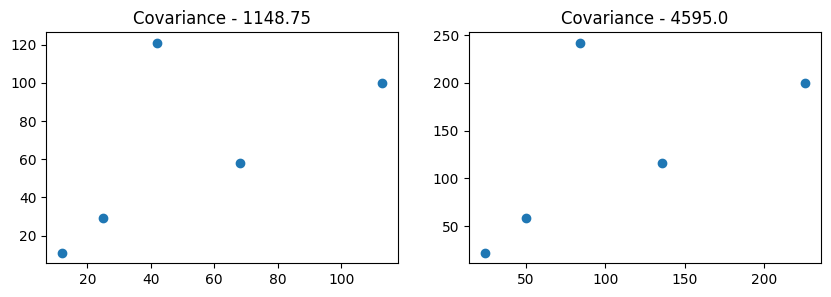

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot scatterplots on each axes
ax1.scatter(df['x'], df['y'])
ax2.scatter(df['x']*2, df['y']*2)

ax1.set_title("Covariance - " + str(np.cov(df['x'],df['y'])[0,1]))
ax2.set_title("Covariance - " + str(np.cov(df['x']*2,df['y']*2)[0,1]))

In [5]:
print(np.cov(df['x'],df['y'])[0,1])
print(np.cov(df['x']*2,df['y']*2)[0,1])

1148.75
4595.0


Text(0.5, 1.0, 'Covariance - 4595.0')

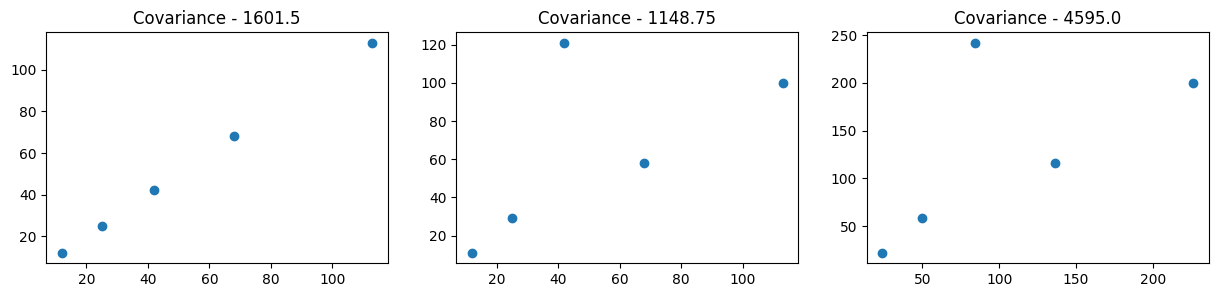

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3))

# Plot scatterplots on each axes
ax[0].scatter(df['x'], df['x'])
ax[1].scatter(df['x'], df['y'])
ax[2].scatter(df['x']*2, df['y']*2)

ax[0].set_title("Covariance - " + str(np.cov(df['x'],df['x'])[0,1]))
ax[1].set_title("Covariance - " + str(np.cov(df['x'],df['y'])[0,1]))
ax[2].set_title("Covariance - " + str(np.cov(df['x']*2,df['y']*2)[0,1]))


Text(0.5, 1.0, 'Correlation - 0.6185423626205997')

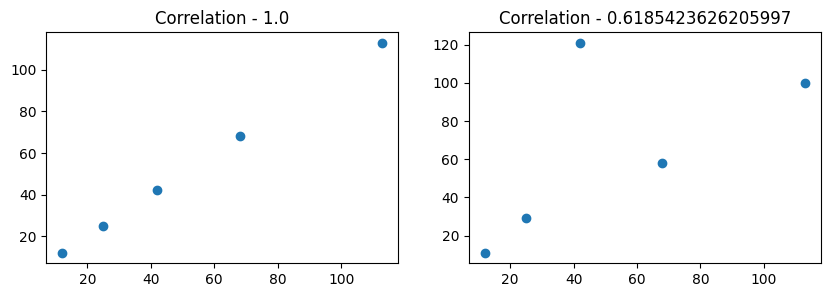

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot scatterplots on each axes
ax1.scatter(df['x'], df['x'])
ax2.scatter(df['x'], df['y'])

ax1.set_title("Correlation - " + str(df['x'].corr(df['x'])))
ax2.set_title("Correlation - " + str((df['x']).corr(df['y'])))

Text(0.5, 1.0, 'Correlation - 0.6185423626205997')

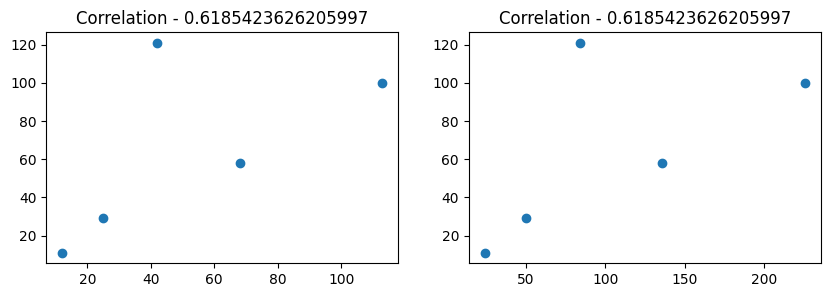

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot scatterplots on each axes
ax1.scatter(df['x'], df['y'])
ax2.scatter(df['x']*2, df['y'])

ax1.set_title("Correlation - " + str(df['x'].corr(df['y'])))
ax2.set_title("Correlation - " + str((df['x']*2).corr(df['y']*2)))

#### ***Probability Distribution Function***

In [1]:
import pandas as pd 
import random

L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)
  L.append(a + b)

In [2]:
L[:5]

[5, 11, 7, 12, 7]

In [3]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()
import numpy as np
np.cumsum(s)

2     0.0288
3     0.0837
4     0.1695
5     0.2802
6     0.4160
7     0.5869
8     0.7201
9     0.8348
10    0.9155
11    0.9693
12    1.0000
Name: count, dtype: float64

<Axes: >

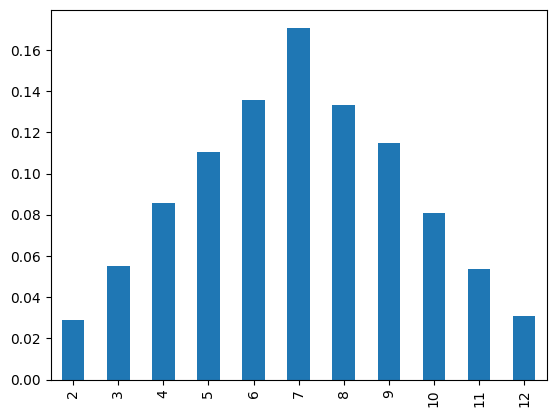

In [4]:
s.plot(kind='bar')

<Axes: >

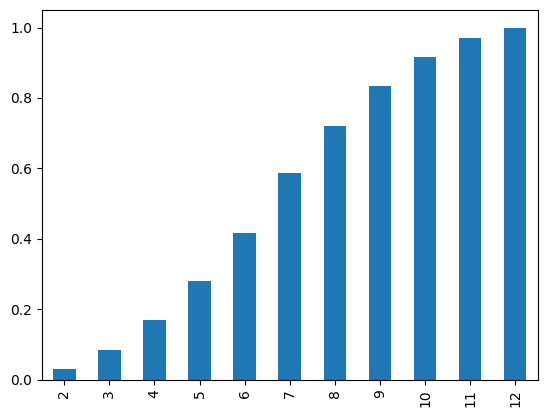

In [5]:
np.cumsum(s).plot(kind='bar')

- ***Parametric Density Estimations***

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

sample = normal(loc=50, scale=5,size=1000)

In [9]:
print(sample.mean())

49.693068871644684


(array([  4.,  30.,  76., 179., 291., 220., 129.,  51.,  19.,   1.]),
 array([33.10677681, 36.58857533, 40.07037384, 43.55217235, 47.03397086,
        50.51576938, 53.99756789, 57.4793664 , 60.96116491, 64.44296342,
        67.92476194]),
 <BarContainer object of 10 artists>)

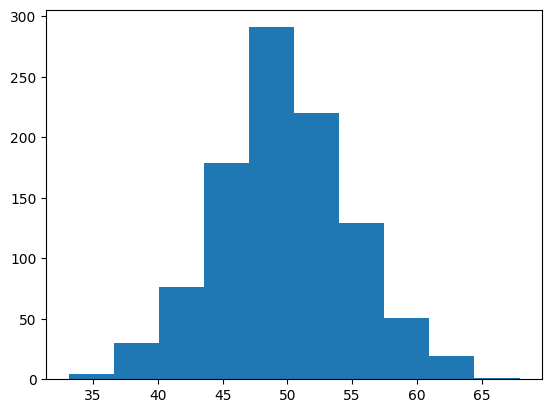

In [10]:
plt.hist(sample,bins=10)

In [11]:
sample_mean = sample.mean()
sample_std = sample.std()

from scipy.stats import norm
dist = norm(60, 12)
values = np.linspace(sample.min(),sample.max(),100)

In [13]:
print(sample.max())

67.92476193661977


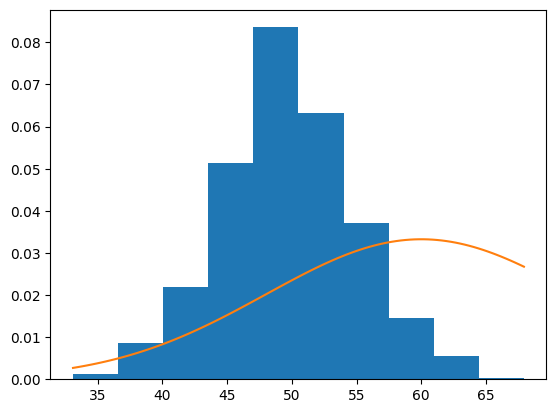

In [14]:
probabilities = [dist.pdf(value) for value in values]

plt.hist(sample,bins=10,density=True)
plt.plot(values,probabilities)

C:\Users\gzbra\AppData\Local\Temp\ipykernel_15340\1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

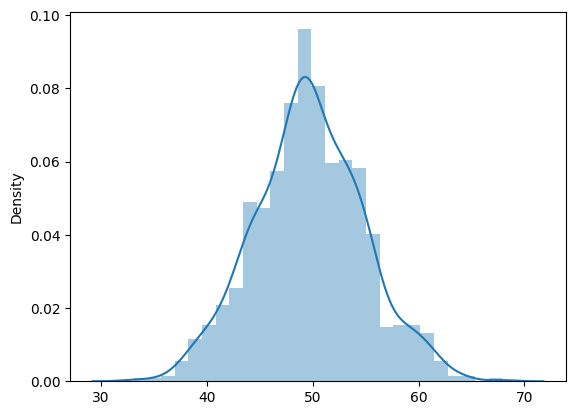

In [15]:
import seaborn as sns
sns.distplot(sample)

In [17]:
# KDE
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

(array([ 1.,  0.,  0.,  0.,  0.,  1.,  2.,  3.,  5.,  8.,  4., 14., 12.,
        25., 26., 21., 21., 27., 23., 29., 19., 15., 15., 11., 16.,  8.,
         8.,  8., 14., 27., 17., 36., 40., 53., 65., 52., 57., 59., 42.,
        50., 41., 44., 36., 16., 11., 10.,  3.,  3.,  1.,  1.]),
 array([ 1.96355791,  3.01238843,  4.06121895,  5.11004947,  6.15887999,
         7.20771051,  8.25654103,  9.30537155, 10.35420207, 11.40303259,
        12.45186311, 13.50069363, 14.54952415, 15.59835467, 16.64718519,
        17.69601571, 18.74484623, 19.79367675, 20.84250726, 21.89133778,
        22.9401683 , 23.98899882, 25.03782934, 26.08665986, 27.13549038,
        28.1843209 , 29.23315142, 30.28198194, 31.33081246, 32.37964298,
        33.4284735 , 34.47730402, 35.52613454, 36.57496506, 37.62379558,
        38.6726261 , 39.72145662, 40.77028714, 41.81911766, 42.86794818,
        43.9167787 , 44.96560921, 46.01443973, 47.06327025, 48.11210077,
        49.16093129, 50.20976181, 51.25859233, 52.30742285,

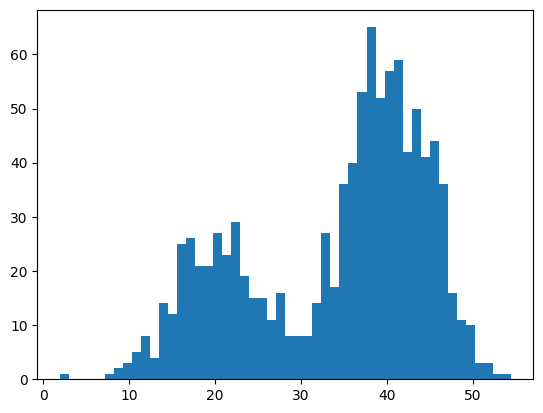

In [18]:
plt.hist(sample,bins=50)

In [19]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=5, kernel='gaussian')

# convert data to a 2D array
sample = sample.reshape((len(sample), 1))
model.fit(sample)

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",5
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None
Name,Type,Value
"bandwidth_ bandwidth_: floatValue of the bandwidth, given directly by the bandwidth parameter orestimated using the 'scott' or 'silverman' method... versionadded:: 1.0",int,5


In [20]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values), 1))

probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

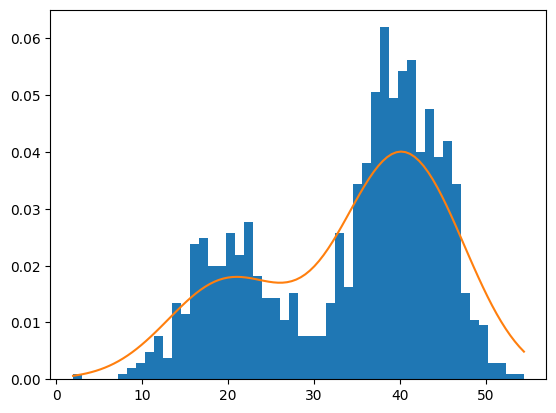

In [21]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

<Axes: ylabel='Density'>

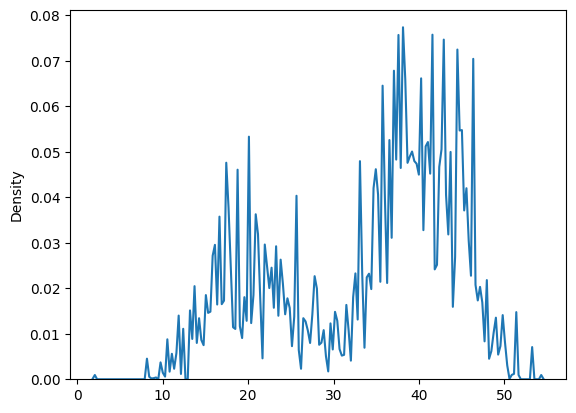

In [22]:
sns.kdeplot(sample.reshape(1000),bw_adjust=0.02)

In [23]:
import seaborn as sns 
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_width', ylabel='Density'>

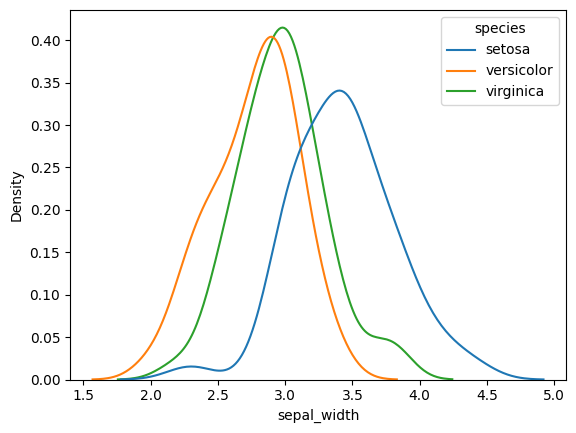

In [24]:
sns.kdeplot(data=df,x='sepal_width',hue='species')

<Axes: xlabel='sepal_length', ylabel='Density'>

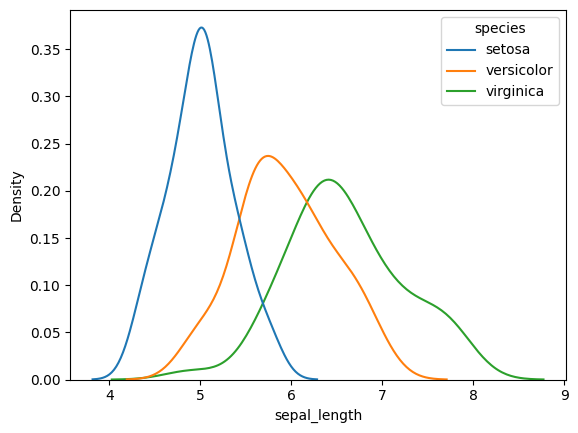

In [25]:
sns.kdeplot(data=df,x='sepal_length',hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

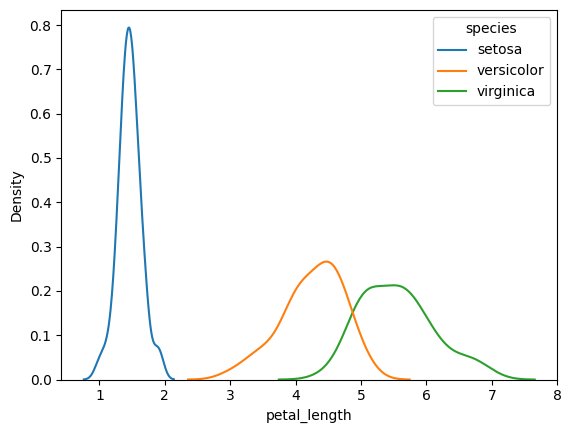

In [26]:
sns.kdeplot(data=df,x='petal_length',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

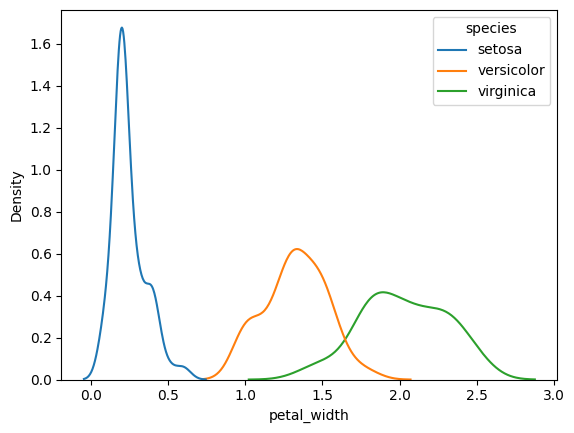

In [27]:
sns.kdeplot(data=df,x='petal_width',hue='species')